In [2]:

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn import linear_model
reg = linear_model.LinearRegression()
reg.fit([[0, 0], [1, 1], [2, 2]], [0, 1, 2])
reg.coef_

array([0.5, 0.5])

Dealing with Missing Values

In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the data
data = sns.load_dataset('titanic')
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


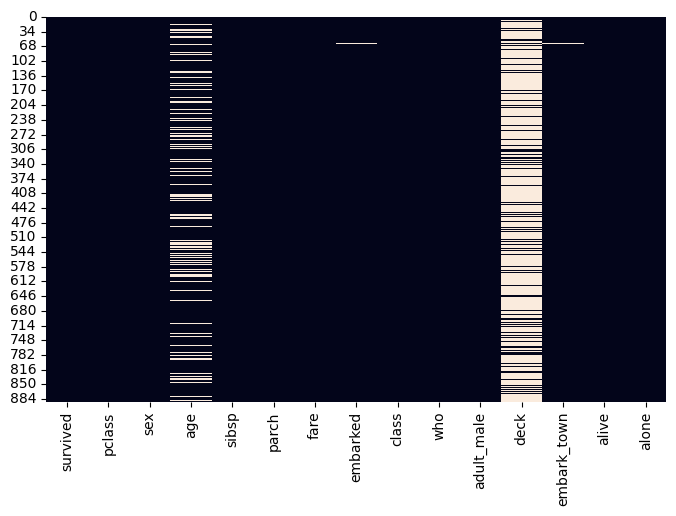

In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load titanic dataset
data = sns.load_dataset('titanic')

# Visualize the data
plt.figure(figsize=(8, 5))
sns.heatmap(data.isnull(), cbar=False)
plt.show()

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [7]:
data.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [8]:
round(data.isnull().sum() / len(data) * 100, 2).sort_values(ascending=False)

deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
sex             0.00
pclass          0.00
survived        0.00
fare            0.00
parch           0.00
sibsp           0.00
class           0.00
adult_male      0.00
who             0.00
alive           0.00
alone           0.00
dtype: float64

In [10]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
# load titanic dataset
data = sns.load_dataset('titanic')

# calculate missing values
print("----------------------------------------")
print(f"Missing values in each column:\n{data.isnull().sum().sort_values(ascending=False)}")
print("----------------------------------------")
print(f"Percentage of missing values in each column:\n{round(data.isnull().sum() / len(data) * 100, 2).sort_values(ascending=False)}")

----------------------------------------
Missing values in each column:
deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64
----------------------------------------
Percentage of missing values in each column:
deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
sex             0.00
pclass          0.00
survived        0.00
fare            0.00
parch           0.00
sibsp           0.00
class           0.00
adult_male      0.00
who             0.00
alive           0.00
alone           0.00
dtype: float64


In [12]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
round(data['age'].mean(), 2)

np.float64(29.7)

In [14]:
data['age'].median()

np.float64(28.0)

In [18]:
# Mean of age to fill age missing values
data['age'] = data['age'].fillna(data['age'].median())

In [19]:
# drop deck column
data.drop('deck', axis=1, inplace=True)

In [20]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [21]:
data['embark_town'].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [25]:
# replacing embarked missing values with mode
data['embark_town'] = data['embark_town'].fillna(data['embark_town'].mode()[0])
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])

In [26]:

data.isnull().sum().sort_values(ascending=False)

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

- we can also impute using sk learn


In [27]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.impute import SimpleImputer

In [28]:
df = sns.load_dataset('titanic')

In [29]:
# impute age column using simpleimputer from sklearn
imputer = SimpleImputer(strategy='median')
df['age'] = imputer.fit_transform(df[['age']])

In [30]:
df.isnull().sum().sort_values(ascending=False)

deck           688
embarked         2
embark_town      2
age              0
survived         0
pclass           0
sex              0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

- multivariate imputation

In [31]:
df = sns.load_dataset('titanic')

In [32]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [33]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# impute age column using iterativeimputer from sklearn
imputer = IterativeImputer(max_iter=20, n_nearest_features=5)
df['age'] = imputer.fit_transform(df[['age']])

In [34]:
df.isnull().sum().sort_values(ascending=False)

deck           688
embarked         2
embark_town      2
age              0
survived         0
pclass           0
sex              0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

- ffill and backward fill

In [35]:
df = sns.load_dataset('titanic')

In [36]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [37]:
# using forward fill impute age column
df['age'] = df['age'].bfill()

- using KNN imputer

In [38]:
from sklearn.impute import KNNImputer

# impute age column using KNNImputer from sklearn
imputer = KNNImputer(n_neighbors=5)
df['age'] = imputer.fit_transform(df[['age']])

In [39]:
# drop rows having missing values
df.dropna(inplace=True)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 1 to 889
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     201 non-null    int64   
 1   pclass       201 non-null    int64   
 2   sex          201 non-null    object  
 3   age          201 non-null    float64 
 4   sibsp        201 non-null    int64   
 5   parch        201 non-null    int64   
 6   fare         201 non-null    float64 
 7   embarked     201 non-null    object  
 8   class        201 non-null    category
 9   who          201 non-null    object  
 10  adult_male   201 non-null    bool    
 11  deck         201 non-null    category
 12  embark_town  201 non-null    object  
 13  alive        201 non-null    object  
 14  alone        201 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 20.1+ KB


In [41]:
df.isnull().sum().sort_values(ascending=False)

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 201 entries, 1 to 889
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     201 non-null    int64   
 1   pclass       201 non-null    int64   
 2   sex          201 non-null    object  
 3   age          201 non-null    float64 
 4   sibsp        201 non-null    int64   
 5   parch        201 non-null    int64   
 6   fare         201 non-null    float64 
 7   embarked     201 non-null    object  
 8   class        201 non-null    category
 9   who          201 non-null    object  
 10  adult_male   201 non-null    bool    
 11  deck         201 non-null    category
 12  embark_town  201 non-null    object  
 13  alive        201 non-null    object  
 14  alone        201 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 20.1+ KB


- 03_inconsistencies_in_data

In [1]:
import pandas as pd

In [2]:
data = {
    'date': ['2021-12-01', '01-12-2022', '2022/12/01', '12-01-2021'],
    'country': ['USA', 'U.S.A.', 'America', 'United States'],
    'name': ['Aammar', 'Amaar', 'Hamza', 'Hazma'],
    'sales_2020': [100, 200, None, 200],
    'sales_2021': [None, 150, 300, 150]
}
# make pandas dataframe
df = pd.DataFrame(data)

In [4]:
df.head()

,date,country,name,sales_2020,sales_2021
0,2021-12-01,USA,Aammar,100.0,NaN
1,01-12-2022,U.S.A.,Amaar,200.0,150.0
2,2022/12/01,America,Hamza,NaN,300.0
3,12-01-2021,United States,Hazma,200.0,150.0


In [5]:
# standardizing the date format
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['date'] = df['date'].dt.strftime('%Y-%m-%d')
df.head()

,date,country,name,sales_2020,sales_2021
0,2021-12-01,USA,Aammar,100.0,NaN
1,NaN,U.S.A.,Amaar,200.0,150.0
2,NaN,America,Hamza,NaN,300.0
3,NaN,United States,Hazma,200.0,150.0


In [6]:

# 1. Standardize dates (convert to YYYY-MM-DD format)
# Try multiple date formats
def parse_date(date_str):
    formats = ['%Y-%m-%d', '%d-%m-%Y', '%Y/%m/%d', '%m-%d-%Y']
    for fmt in formats:
        try:
            return pd.to_datetime(date_str, format=fmt).strftime('%Y-%m-%d')
        except:
            continue
    return date_str  # return original if all fail

df['date'] = df['date'].apply(parse_date)

In [7]:
df.head()

,date,country,name,sales_2020,sales_2021
0,2021-12-01,USA,Aammar,100.0,NaN
1,NaN,U.S.A.,Amaar,200.0,150.0
2,NaN,America,Hamza,NaN,300.0
3,NaN,United States,Hazma,200.0,150.0


In [8]:
import pandas as pd
import numpy as np

# Recreate the dataframe
df = pd.DataFrame({
    'date': ['2021-12-01', '01-12-2022', '2022/12/01', '12-01-2021'],
    'country': ['USA', 'U.S.A.', 'America', 'United States'],
    'name': ['Aammar', 'Amaar', 'Hamza', 'Hazma'],
    'sales_2020': [100.0, 200.0, np.nan, 200.0],
    'sales_2021': [np.nan, 150.0, 300.0, 150.0]
})

# 1. Standardize dates (convert to YYYY-MM-DD format)
# Try multiple date formats
def parse_date(date_str):
    formats = ['%Y-%m-%d', '%d-%m-%Y', '%Y/%m/%d', '%m-%d-%Y']
    for fmt in formats:
        try:
            return pd.to_datetime(date_str, format=fmt).strftime('%Y-%m-%d')
        except:
            continue
    return date_str  # return original if all fail

df['date'] = df['date'].apply(parse_date)

# 2. Standardize country names
country_mapping = {
    'USA': 'United States',
    'U.S.A.': 'United States',
    'America': 'United States',
    'United States': 'United States'
}
df['country'] = df['country'].map(country_mapping)

# 3. Handle name inconsistencies (requires domain knowledge)
# Option A: Keep as-is (if they're actually different people)
# Option B: Standardize if you know they're the same person
# For demonstration, I'll keep them but flag potential duplicates
df['name_cleaned'] = df['name'].replace({'Aammar': 'Amaar', 'Hazma': 'Hamza'})

# 4. Handle missing values
# Option: Fill with 0 or forward-fill, or keep as NaN
df['sales_2020'] = df['sales_2020'].fillna(0)
df['sales_2021'] = df['sales_2021'].fillna(0)

# Result
print(df)

         date        country    name  sales_2020  sales_2021 name_cleaned
0  2021-12-01  United States  Aammar       100.0         0.0        Amaar
1  2022-12-01  United States   Amaar       200.0       150.0        Amaar
2  2022-12-01  United States   Hamza         0.0       300.0        Hamza
3  2021-01-12  United States   Hazma       200.0       150.0        Hamza


In [9]:
# Correct the typographical Mistakes in name
# Let's assume we want to correct 'Jonh Doe' to 'John Doe'
df['name'] = df['name'].replace({'Amaar': 'Aammar', 'Hazma': 'Hamza'})
df.head()

,date,country,name,sales_2020,sales_2021,name_cleaned
0,2021-12-01,United States,Aammar,100.0,0.0,Amaar
1,2022-12-01,United States,Aammar,200.0,150.0,Amaar
2,2022-12-01,United States,Hamza,0.0,300.0,Hamza
3,2021-01-12,United States,Hamza,200.0,150.0,Hamza


In [10]:
# remove duplicates
df = df.drop_duplicates(subset="name")
df.head()


,date,country,name,sales_2020,sales_2021,name_cleaned
0,2021-12-01,United States,Aammar,100.0,0.0,Amaar
2,2022-12-01,United States,Hamza,0.0,300.0,Hamza


In [11]:
# 5. Resolving Contradictory Data
# For demonstration, let's assume sales_2021 should always be higher than sales_2020
# We'll remove rows where this condition is not met
df = df.drop(df[df['sales_2021'] <= df['sales_2020']].index)
df.head()

,date,country,name,sales_2020,sales_2021,name_cleaned
2,2022-12-01,United States,Hamza,0.0,300.0,Hamza


In [12]:
import pandas as pd
import numpy as np
from datetime import datetime

# Your original data
data = {
    'date': ['2021-12-01', '01-12-2022', '2022/12/01', '12-01-2021', None],
    'country': ['USA', 'U.S.A.', 'America', 'United States', 'Canada'],
    'name': ['Aammar', 'Amaar', 'Hamza', 'Hazma', 'John'],
    'sales_2020': [100, 200, None, 200, 300],
    'sales_2021': [None, 150, 300, 150, 250]
}

df = pd.DataFrame(data)
print("Original Data:")
print(df)
print("\nOriginal date formats:")
print(df['date'].apply(lambda x: type(x).__name__ if pd.isna(x) else f"'{x}'"))

# ─────────────────────────────────────────────────────────────────────────────
# METHOD 1: Basic conversion (already done - but improved)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("METHOD 1: Basic pd.to_datetime() conversion")
print("="*80)
df['date_basic'] = pd.to_datetime(df['date'], errors='coerce')
df['date_basic_formatted'] = df['date_basic'].dt.strftime('%Y-%m-%d')
print(df[['date', 'date_basic', 'date_basic_formatted']])

# ─────────────────────────────────────────────────────────────────────────────
# METHOD 2: Explicit format handling for ambiguous dates (DD-MM-YYYY vs MM-DD-YYYY)
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*80)
print("METHOD 2: Day-first parsing for ambiguous dates")
print("="*80)

def parse_with_priority(date_str, dayfirst=True):
    """Parse dates with explicit dayfirst/monthfirst priority"""
    try:
        return pd.to_datetime(date_str, dayfirst=dayfirst, errors='coerce')
    except:
        return pd.NaT

# Try dayfirst=True (DD-MM-YYYY priority)
df['date_dayfirst'] = df['date'].apply(parse_with_priority, dayfirst=True)

# Try dayfirst=False (MM-DD-YYYY priority) 
df['date_monthfirst'] = df['date'].apply(parse_with_priority, dayfirst=False)

# Choose the most appropriate based on your data context
# For international data, dayfirst=True is often safer
df['date_standardized'] = df['date_dayfirst']
df['date_standardized_str'] = df['date_standardized'].dt.strftime('%Y-%m-%d')

print(df[['date', 'date_dayfirst', 'date_monthfirst', 'date_standardized_str']])

Original Data:
         date        country    name  sales_2020  sales_2021
0  2021-12-01            USA  Aammar       100.0         NaN
1  01-12-2022         U.S.A.   Amaar       200.0       150.0
2  2022/12/01        America   Hamza         NaN       300.0
3  12-01-2021  United States   Hazma       200.0       150.0
4        None         Canada    John       300.0       250.0

Original date formats:
0    '2021-12-01'
1    '01-12-2022'
2    '2022/12/01'
3    '12-01-2021'
4        NoneType
Name: date, dtype: object

METHOD 1: Basic pd.to_datetime() conversion
         date date_basic date_basic_formatted
0  2021-12-01 2021-12-01           2021-12-01
1  01-12-2022        NaT                  NaN
2  2022/12/01        NaT                  NaN
3  12-01-2021        NaT                  NaN
4        None        NaT                  NaN

METHOD 2: Day-first parsing for ambiguous dates
         date date_dayfirst date_monthfirst date_standardized_str
0  2021-12-01    2021-01-12      2021-12-01